<a href="https://colab.research.google.com/github/susu-xxx/MyStudy/blob/DeepLearning/DeepLearning_%EB%A7%9B%EB%B3%B4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 딥러닝이란?
- 인간 신경망을 모방하여 학습, 및 예측하고 판단하는 기술
- 영상 처리 , 음성 처리, 이미지 분야, 텍스트, 자연어 처리 등

- colab : 구글이 만든 파이썬 에디터
- tensorflow : 구글이 만든 딥러닝 프레임워크()라이브러리
-keras : tensorflow 위에서 동작하는 사용자 친화적 라이브러리

In [ ]:
import tensorflow as tf
tf.__version__ #설치버전 확인

'2.18.0'

In [ ]:
# 코랩은 이눅스 기반
# 현재 작업 디렉토리 확인 가능
!pwd

/content/drive/My Drive/Colab Notebooks/SW엔지니어


In [ ]:
# 파일 영구저장을 위한 구글 드라이브 연동(마운트)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#작업 디렉토리 변경
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


In [ ]:
#### 목표

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# csv 파일 불러오기

data = pd.read_csv('./data/student-mat.csv', delimiter=';')
data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


| 컬럼 이름       | 설명                             |
|-----------------|----------------------------------|
| school          | 학교 (GP - Gabriel Pereira, MS - Mousinho da Silveira) |
| sex             | 성별 (F - Female, M - Male)      |
| age             | 나이                             |
| address         | 주소 유형 (U - Urban, R - Rural) |
| famsize         | 가족 크기 (LE3 - 3명 이하, GT3 - 3명 초과) |
| Pstatus         | 부모 동거 상태 (T - 함께, A - 별거) |
| Medu            | 어머니 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Fedu            | 아버지 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Mjob            | 어머니 직업 (teacher, health, services, at_home, other) |
| Fjob            | 아버지 직업 (teacher, health, services, at_home, other) |
| reason          | 학교 선택 이유 (home, reputation, course, other) |
| guardian        | 보호자 (mother, father, other)  |
| traveltime      | 통학 시간 (1 - 15분 이하, 2 - 15~30분, 3 - 30분~1시간, 4 - 1시간 초과) |
| studytime       | 주간 공부 시간 (1 - 2시간 이하, 2 - 2~5시간, 3 - 5~10시간, 4 - 10시간 초과) |
| failures        | 과목 낙제 수 (n if 1<=n<3, else 4) |
| schoolsup       | 학교 추가 지원 (yes, no)        |
| famsup          | 가족 추가 지원 (yes, no)        |
| paid            | 과외 수업 참여 (yes, no)        |
| activities      | 학교 외 활동 참여 (yes, no)     |
| nursery         | 유치원 참여 여부 (yes, no)      |
| higher          | 고등교육 희망 여부 (yes, no)    |
| internet        | 가정 내 인터넷 접속 여부 (yes, no) |
| romantic        | 로맨틱 관계 여부 (yes, no)      |
| famrel          | 가족 관계의 질 (1 - 매우 나쁨, 5 - 매우 좋음) |
| freetime        | 여가 시간의 양 (1 - 매우 적음, 5 - 매우 많음) |
| goout           | 외출 빈도 (1 - 매우 적음, 5 - 매우 많음) |
| Dalc            | 평일 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| Walc            | 주말 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| health          | 현재 건강 상태 (1 - 매우 나쁨, 5 - 매우 좋음) |
| absences        | 결석 일수                        |
| G1              | 1학기 성적                       |
| G2              | 2학기 성적                       |
| G3              | 최종 성적                        |


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

#### 문제와 정답데이터로 분리
- 입력특성 : studytime
- 정답 : G3

In [ ]:
x = data[['studytime']]
y = data['G3']

In [ ]:
x.shape,y.shape

((395, 1), (395,))

In [ ]:
#train, test 분리
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=2025)

In [ ]:
# 크기 확인
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((276, 1), (119, 1), (276,), (119,))

## 머신러닝과 딥러닝 모델링 비교


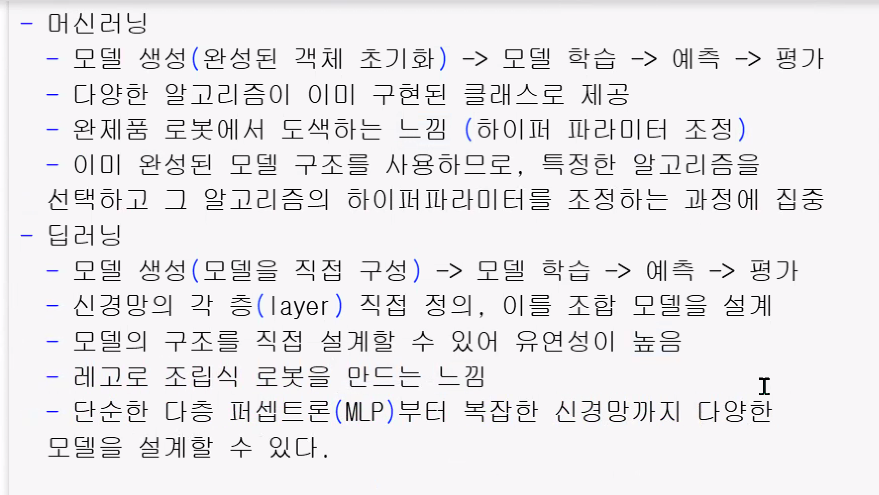

In [ ]:
# 일반 선형회귀 모델, 학습 및 평가
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
lr_model = LinearRegression()
lr_model.fit(x_train,y_train)
y_pred = lr_model.predict(x_test) # 예측값
mse = mean_squared_error(y_test,y_pred) # 실제값과 예측값을 이용해 MSE  구함
print("평균 제곱 오차 :", mse)

평균 제곱 오차 : 23.164188168213375


딥러닝 모델링

1. 신경망 구조 설계
2. 신경망 학습 방법 및 평가방법 설정
3. 모델 학습
4. 예측 및 평가

In [ ]:
# tensorflow 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import InputLayer

#Sequential : 뼈대 , 층(layer)를 순차적으로 쌓아 올리는 구조
# Denser : layer 층
# InputLayer : 입력층

In [ ]:
#1. 신경망 구조 설계

#특성 뼈대 생성
model = Sequential()

 # 입력층 : 입력 데이터의 형태를 결정
model.add(InputLayer(input_shape = (1,)))

 #add() : 딥러닝 모델이 Dense(층)을 쌓는 기능
 #Dense (): 하나의 층

 #중간층(은닉층)
model.add(Dense(units= 64, activation = 'sigmoid'))
model.add(Dense(units= 64, activation = 'sigmoid'))

 # units : 뉴런 개수(퍼셉트론 개수 ))

 #출력층
model.add(Dense(units= 1))# 1개의 뉴런으로 구성된 출력층
#출력 데이터의 형태에 따라 유닛 수를 결정 (이번 실습에서는 연속형 데이터 한 개 )



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
#2. 학습 방법 및 평가 방법 설정
model.compile(optimizer = 'SGD', #최적화 함수, adam이 좋음
              loss = 'mean_squared_error',
              metrics = ['mse'] # 평가방법, 여기서는 mse
              )

In [ ]:
#3. 모델 학습
h = model.fit(x_train, y_train, epochs = 20, #전체 훈련 데이터셋을 사용하여
                validation_split = 0.2 #훈련 데이터의 20%를 검증 데이터로 사용
# 7/7 전체 데이터셋을 7개의 배치로 나누어서 학습했음을 의미, # 276*0.8 = 221/32 = 6.9
              )

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 19.6959 - mse: 19.6959 - val_loss: 21.6497 - val_mse: 21.6497
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20.3612 - mse: 20.3612 - val_loss: 21.2205 - val_mse: 21.2205
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 19.9483 - mse: 19.9483 - val_loss: 21.3583 - val_mse: 21.3583
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 20.2510 - mse: 20.2510 - val_loss: 21.5193 - val_mse: 21.5193
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 21.5137 - mse: 21.5137 - val_loss: 21.4054 - val_mse: 21.4054
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 22.4370 - mse: 22.4370 - val_loss: 21.4610 - val_mse: 21.4610
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 20.0573 - mse: 20.0573 - val_loss: 21.5496 - val_mse: 21.5496
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 20.3416 - mse: 20.3416 - val_loss: 21.9415 - val_mse: 21.9415
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

In [ ]:
# 4. 모델 평가 ]
# evaluate() : 머신러닝의 score와 비슷한 함수
# 가장 마지막 학습의 결과로 평가
model.evaluate(x_test, y_test)

# 손실함수, mse


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 25.5580 - mse: 25.5580


[22.690534591674805, 22.690534591674805]

In [ ]:
# 매 eporch마다 결과값이 들어감
h.history.keys()

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

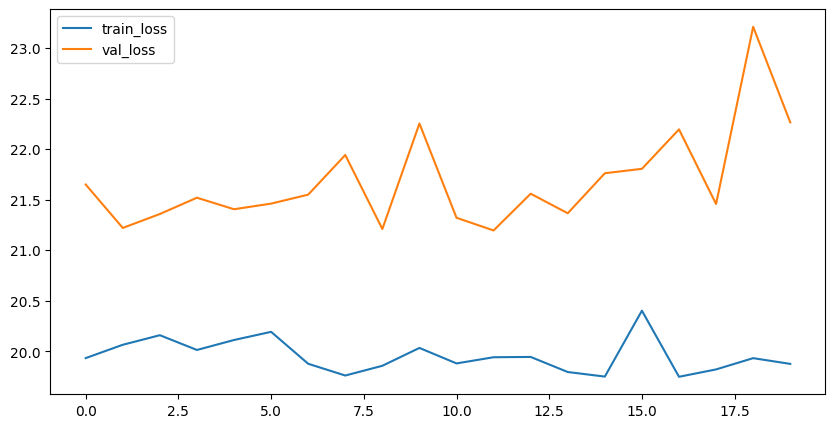

In [ ]:
# 학습 결과 시각화
plt.figure(figsize= (10,5))
plt.plot(h.history['loss'], label = 'train_loss')

plt.plot(h.history['val_loss'], label = 'val_loss')
plt.legend() #범례
plt.show()

#초기 에포크 동안 손실 값이 급격히 변동
#이느 모델이 초기 학습 단계에서 최적의 가중치 값을 찾기 위해 많은 조정이 이루어진다 .

# 검증 손실값은 학습이 진행되도록 개선이 이루어지지 않음.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
